In [ ]:
%pip install rohub pandas

In [219]:
import rohub

USE_DEVELOPMENT_VERSION = True

In [220]:
if USE_DEVELOPMENT_VERSION:
    rohub.settings.API_URL = "ttps://rohub2020-devel.apps.bst2.paas.psnc.pl/api/"
    rohub.settings.KEYCLOAK_CLIENT_ID = "rohub2020-cli"
    rohub.settings.KEYCLOAK_CLIENT_SECRET = "714617a7-87bc-4a88-8682-5f9c2f60337d"
    rohub.settings.KEYCLOAK_URL = "https://keycloak-dev.apps.paas-dev.psnc.pl/auth/realms/rohub/protocol/openid-connect/token"
    rohub.settings.SPARQL_ENDPOINT = "https://virtuoso-rohub2020-devel.apps.bst2.paas.psnc.pl/sparql"
else:
    rohub.settings.API_URL = "https://api.rohub.org/api/"
    rohub.settings.KEYCLOAK_CLIENT_ID = "rohub2020-public-cli"
    rohub.settings.KEYCLOAK_URL = "https://login.rohub.org/auth/realms/rohub/protocol/openid-connect/token"
    rohub.settings.SPARQL_ENDPOINT = "https://virtuoso-rohub2020-production.apps.bst2.paas.psnc.pl/sparql"

In [ ]:
username = ""
password = ""

rohub.login(username=username, password=password)

In [303]:
ANNOTATION_PREDICATE = "http://w3id.org/nfdi4ing/metadata4ing#investigates"
ANNOTATION_OBJECT = "https://github.com/Simulation-Benchmarks/linear-elastic-plate-with-hole"

In [ ]:
UUID_QUERY = f"""
SELECT ?subject 
WHERE {{
  ?subject <{ANNOTATION_PREDICATE}> <{ANNOTATION_OBJECT}> .
}}
"""

uuid_result = rohub.query_sparql_endpoint(UUID_QUERY, endpoint_url=rohub.settings.SPARQL_ENDPOINT)
uuids = []
  
if not uuid_result.empty:
    uuids = [iri.split('/')[-1] for iri in uuid_result["subject"]]
    print("UUIDs:", uuids)
else:
    uuids = []
    print("No results found")

In [ ]:
named_graphs = {}

for UUID in uuids:
    RO_ID_BASE = "ro-id-dev" if USE_DEVELOPMENT_VERSION else "ro-id"
    NAMED_GRAPH_QUERY = f"""
    PREFIX schema: <http://schema.org/>
    SELECT ?graph WHERE {{
        GRAPH ?graph {{ <https://w3id.org/{RO_ID_BASE}/{UUID}> a schema:Dataset . }}
    }}
    """

    named_graph_result = rohub.query_sparql_endpoint(NAMED_GRAPH_QUERY, endpoint_url=rohub.settings.SPARQL_ENDPOINT)

    if not named_graph_result.empty:
        graph_iri = named_graph_result.iloc[0]["graph"]
        named_graphs[UUID] = graph_iri
        print(f"[{UUID}] Found Named Graph: {graph_iri}")

In [306]:
import sys
import os
import importlib

provenance_path = os.path.abspath(os.path.join('..', 'provenance'))

import provenance

if provenance_path not in sys.path:
    sys.path.append(provenance_path)
        
importlib.reload(provenance)
analyzer = provenance.ProvenanceAnalyzer()

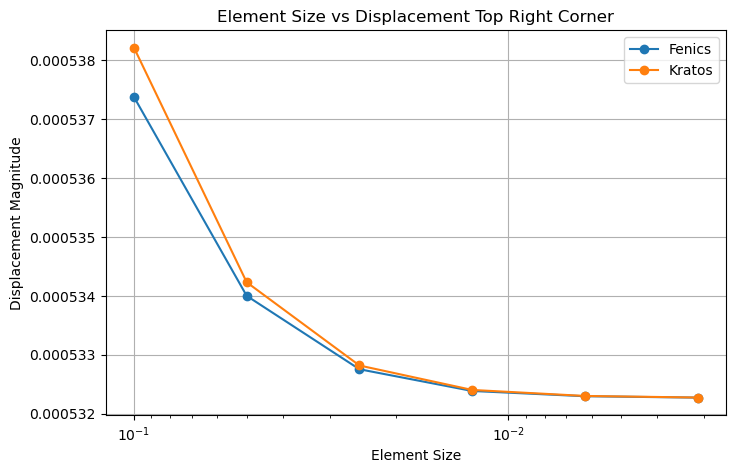

In [314]:

parameters = ["element_size", "isoparametric_element_degree"]
metrics = ["displacement_top_right_corner"]

query_string = analyzer.build_dynamic_rohub_query(parameters, metrics, named_graphs.values())

df = rohub.query_sparql_endpoint(query_string, endpoint_url=rohub.settings.SPARQL_ENDPOINT)
df =  (df[df["isoparametric_element_degree"] == "1"].drop(columns=["isoparametric_element_degree"]))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Split into x and y components
df[["disp_x", "disp_y"]] = (
    df["displacement_top_right_corner"]
    .str.split(",", expand=True)
    .astype(float)
)

# Compute displacement magnitude
df["disp_mag"] = np.sqrt(
    df["disp_x"]**2 +
    df["disp_y"]**2
)

# Ensure element_size is numeric
df["element_size"] = pd.to_numeric(df["element_size"])

# Plot
plt.figure(figsize=(8, 5))

for tool, group in df.groupby("tool_name"):
    group = group.sort_values("element_size")

    plt.plot(
        group["element_size"],
        group["disp_mag"],
        marker="o",
        label=tool
    )

plt.xscale("log")
plt.gca().invert_xaxis() 

plt.xlabel("Element Size")
plt.ylabel("Displacement Magnitude")
plt.title("Element Size vs Displacement Top Right Corner")
plt.grid(True)
plt.legend()
plt.show()


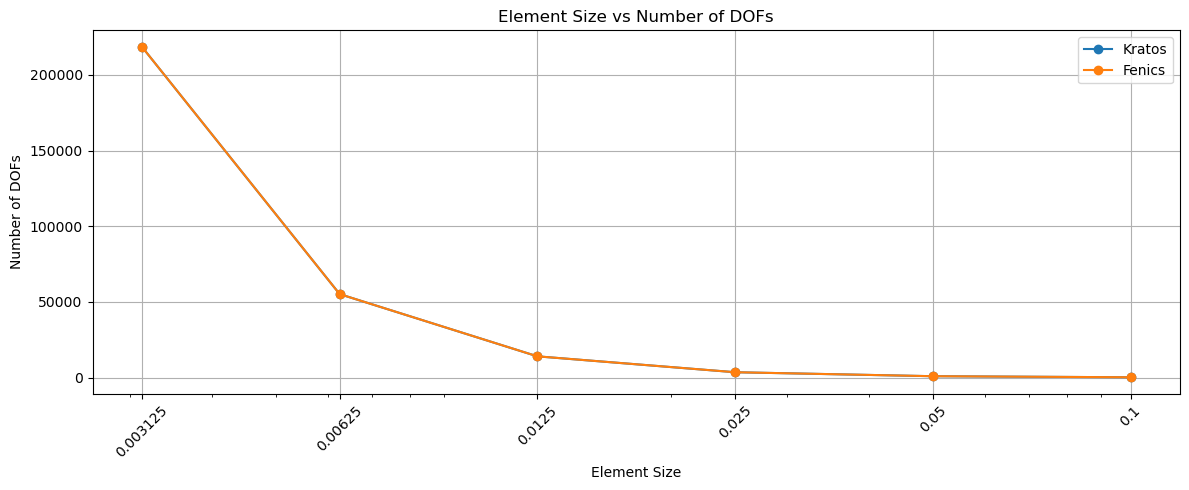

In [313]:
parameters = ["element_size", "isoparametric_element_degree"]
metrics = ["number_of_dofs"]

query_string = analyzer.build_dynamic_rohub_query(parameters, metrics, named_graphs.values())

df = rohub.query_sparql_endpoint(query_string, endpoint_url=rohub.settings.SPARQL_ENDPOINT)
result =  (df[df["isoparametric_element_degree"] == "1"].drop(columns=["isoparametric_element_degree"]))

analyzer.plot_provenance_graph_rohub(
    data=result.values.tolist(),
    x_axis_label="Element Size",
    y_axis_label="Number of DOFs",
    group_index=0,
    x_axis_index=1,
    y_axis_index=2,
    title="Element Size vs Number of DOFs",
)

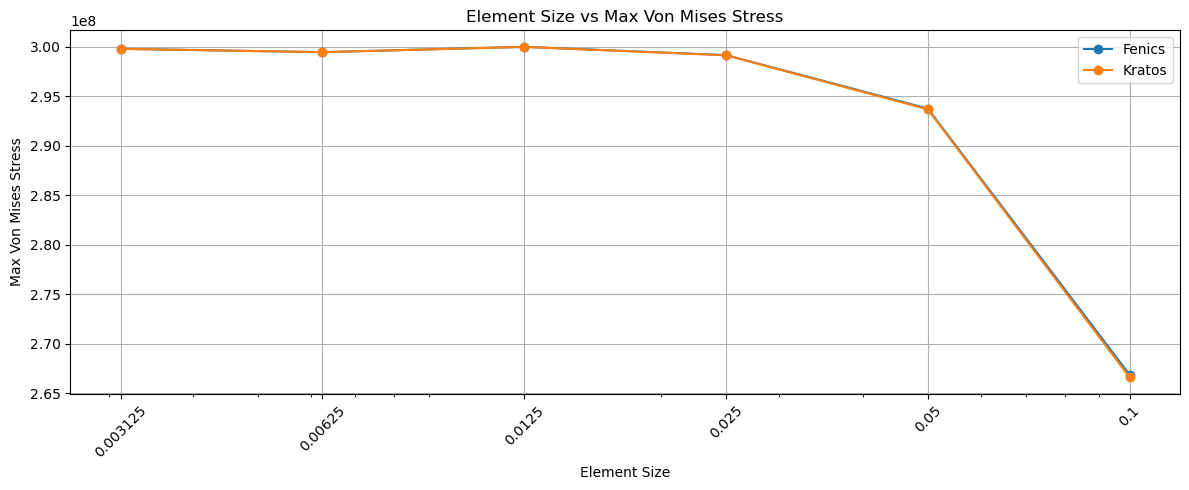

In [151]:
parameters = ["element_size", "isoparametric_element_degree"]
metrics = ["max_von_mises_stress"]

query_string = analyzer.build_dynamic_rohub_query(parameters, metrics, named_graphs.values())

df = rohub.query_sparql_endpoint(query_string, endpoint_url=rohub.settings.SPARQL_ENDPOINT)
result =  (df[df["isoparametric_element_degree"] == "1"].drop(columns=["isoparametric_element_degree"]))

analyzer.plot_provenance_graph_rohub(
    data=result.values.tolist(),
    x_axis_label="Element Size",
    y_axis_label="Max Von Mises Stress",
    group_index=0,
    x_axis_index=1,
    y_axis_index=2,
    title="Element Size vs Max Von Mises Stress",
)

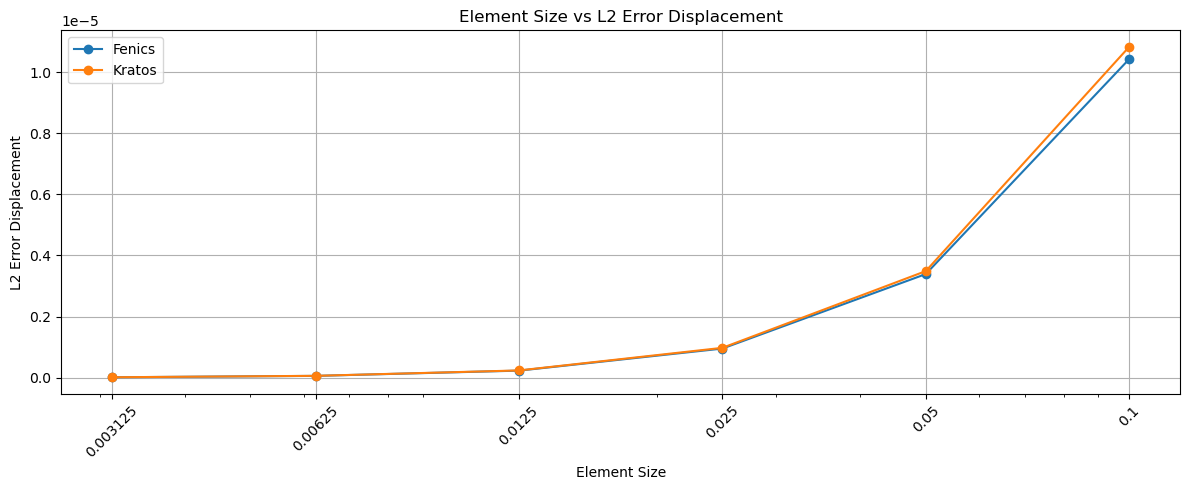

In [152]:
parameters = ["element_size", "isoparametric_element_degree"]
metrics = ["l2_error_displacement"]

query_string = analyzer.build_dynamic_rohub_query(parameters, metrics, named_graphs.values())
df = rohub.query_sparql_endpoint(query_string, endpoint_url=rohub.settings.SPARQL_ENDPOINT)
result =  (df[df["isoparametric_element_degree"] == "1"].drop(columns=["isoparametric_element_degree"]))

analyzer.plot_provenance_graph_rohub(
    data=result.values.tolist(),
    x_axis_label="Element Size",
    y_axis_label="L2 Error Displacement",
    group_index=0,
    x_axis_index=1,
    y_axis_index=2,
    title="Element Size vs L2 Error Displacement",
)

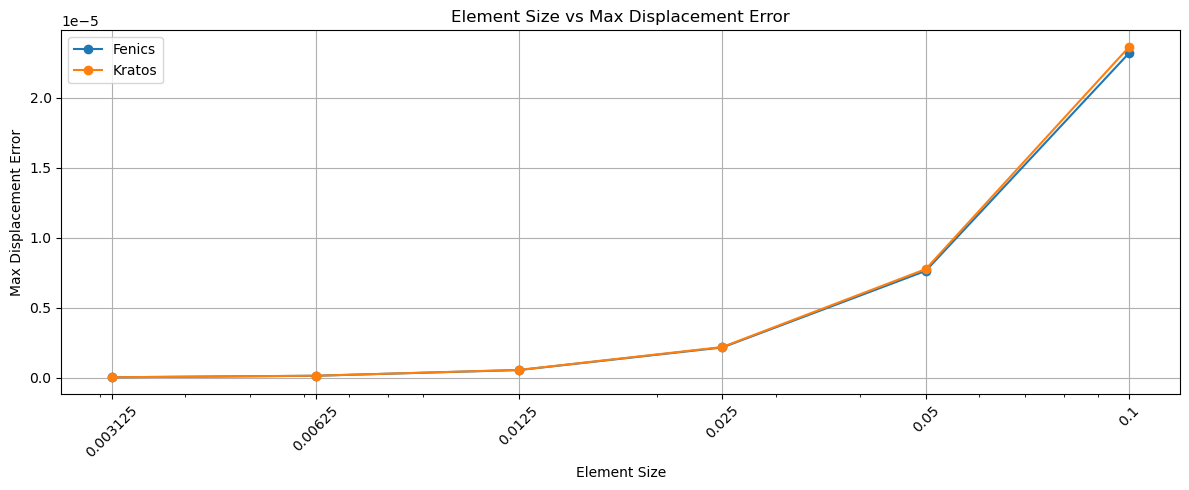

In [153]:
parameters = ["element_size", "isoparametric_element_degree"]
metrics = ["max_displacement_error"]

query_string = analyzer.build_dynamic_rohub_query(parameters, metrics, named_graphs.values())
df = rohub.query_sparql_endpoint(query_string, endpoint_url=rohub.settings.SPARQL_ENDPOINT)
result =  (df[df["isoparametric_element_degree"] == "1"].drop(columns=["isoparametric_element_degree"]))

analyzer.plot_provenance_graph_rohub(
    data=result.values.tolist(),
    x_axis_label="Element Size",
    y_axis_label="Max Displacement Error",
    group_index=0,
    x_axis_index=1,
    y_axis_index=2,
    title="Element Size vs Max Displacement Error",
)

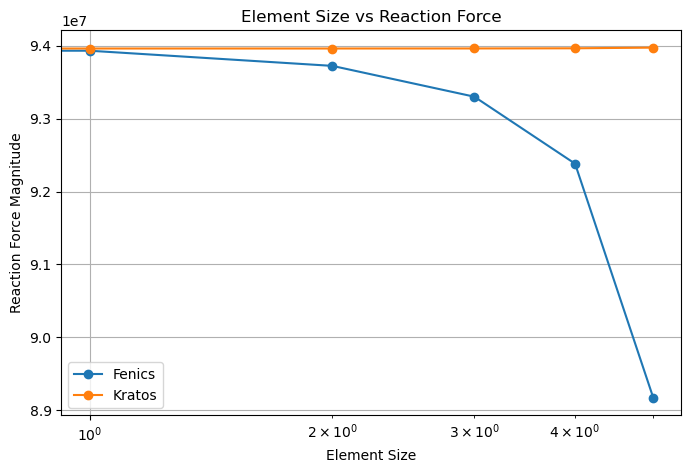

In [154]:
parameters = ["element_size", "isoparametric_element_degree"]
metrics = ["reaction_force_left_boundary_x", "reaction_force_left_boundary_y"]

query_string = analyzer.build_dynamic_rohub_query(parameters, metrics, named_graphs.values())
df = rohub.query_sparql_endpoint(query_string, endpoint_url=rohub.settings.SPARQL_ENDPOINT)
df =  (df[df["isoparametric_element_degree"] == "1"].drop(columns=["isoparametric_element_degree"]))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Convert string columns to numeric
df["reaction_force_left_boundary_x"] = pd.to_numeric(
    df["reaction_force_left_boundary_x"], errors="coerce"
)

df["reaction_force_left_boundary_y"] = pd.to_numeric(
    df["reaction_force_left_boundary_y"], errors="coerce"
)

# Compute force magnitude
df["reaction_force_left_boundary"] = np.sqrt(
    df["reaction_force_left_boundary_x"]**2 +
    df["reaction_force_left_boundary_y"]**2
)

# Plot
df = df.sort_values("element_size")

plt.figure(figsize=(8, 5))

for tool, group in df.groupby("tool_name"):
    plt.plot(
        group["element_size"],
        group["reaction_force_left_boundary"],
        marker="o",
        label=tool
    )

plt.xlabel("Element Size")
plt.ylabel("Reaction Force Magnitude")
plt.title("Element Size vs Reaction Force")
plt.xscale("log") 
plt.grid(True)
plt.legend()
plt.show()
